<a href="https://colab.research.google.com/github/RMoulla/Python_AFD/blob/main/TP_Analyse_Donn%C3%A9es_Cr%C3%A9dit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travaux pratiques : analyse des données de crédit**

In [ ]:
# Lire le fichier csv

import pandas as pd

df = pd.read_csv('german_credit_data.csv')

In [ ]:
# Afficher les premières lignes

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [ ]:
# Statistiques descriptives

df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [ ]:
# Afficher les dimensions du dataframe

df.shape

(1000, 10)

## Nettoyage des données

In [ ]:
# Supprimer la colonne unnamed

df = df.drop('Unnamed: 0', axis=1)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [ ]:
# Afficher les données manquantes

df.isna().sum().sort_values(ascending=False)

,0
Checking account,394
Saving accounts,183
Age,0
Job,0
Sex,0
Housing,0
Credit amount,0
Duration,0
Purpose,0


In [ ]:
# Afficher les lignes contenant des données manquantes

df[df.isna().any(axis=1)].shape

(478, 9)

In [ ]:
# Compléter les données manquantes par "no_info"

df.fillna('no_info', inplace=True)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,no_info,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,no_info,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


## Analyse des données

In [ ]:
# Afficher les premières lignes de la variable âge par ordre croissant
df['Age'].sort_values().head()

,Age
391,19
633,19
296,20
905,20
495,20


In [ ]:
# Afficher les premières lignes de la variable âge par ordre décroissant
df['Age'].sort_values(ascending=False).head()

,Age
536,75
330,75
430,74
606,74
186,74


In [ ]:
# Sélectionner un sous-dataframe

df[['Age', 'Sex']].head()

,Age,Sex
0,67,male
1,22,female
2,49,male
3,45,male
4,53,male


In [ ]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose'],
      dtype='object')

In [ ]:
# Sélectionner des valeurs sur Credit amount

df[df['Credit amount'] > 5000].head(2)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
1,22,female,2,own,little,moderate,5951,48,radio/TV
3,45,male,2,free,little,little,7882,42,furniture/equipment


In [ ]:
df[df['Checking account'] == 'little'].head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,no_info,little,1169,6,radio/TV
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car
11,24,female,2,rent,little,little,4308,48,business
13,60,male,1,own,little,little,1199,24,car


In [ ]:
# Sélection avec une condition complexe "et"

df[(df['Age'] < 25) & (df['Credit amount'] > 10000)].head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
134,21,female,2,own,moderate,no_info,10144,60,radio/TV
236,23,male,0,own,no_info,moderate,14555,6,car
333,24,female,1,rent,moderate,no_info,11590,48,car
637,21,male,2,own,little,no_info,15653,60,radio/TV
736,23,female,3,rent,little,moderate,11560,24,car


In [ ]:
# Ordonner Credit amount par ordre décroissant

df.sort_values('Credit amount', ascending=False).head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
915,32,female,3,own,little,moderate,18424,48,vacation/others
95,58,male,2,rent,little,moderate,15945,54,business
818,43,male,3,own,little,little,15857,36,vacation/others
887,23,male,2,own,little,moderate,15672,48,business
637,21,male,2,own,little,no_info,15653,60,radio/TV


In [ ]:
# Ordonner le dataframe selon deux colonnes Sex et Age

df.sort_values(['Sex', 'Age'], ascending=[False, False]).head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
330,75,male,3,free,little,little,6615,24,car
430,74,male,1,own,little,no_info,3448,5,business
606,74,male,3,own,little,no_info,4526,24,business
756,74,male,0,own,little,rich,1299,6,car
163,70,male,3,free,little,moderate,7308,10,car


## Statistiques descriptives

In [ ]:
# Calculer la moyenne de Credit amount

df['Credit amount'].mean()

np.float64(3271.258)

In [ ]:
# Calculer de la médiane de Credit amount

df['Credit amount'].median()

2319.5

In [ ]:
# Calculer de le maximum de Credit amount

df['Credit amount'].max()

18424

In [ ]:
# Calculer la moyenne de Credit amount en fonction des modalités de Purpose

df.groupby('Purpose')['Credit amount'].mean()

,Credit amount
Purpose,
business,4158.041237
car,3768.192878
domestic appliances,1498.000000
education,2879.203390
furniture/equipment,3066.988950
radio/TV,2487.653571
repairs,2728.090909
vacation/others,8209.333333


In [ ]:
# Calculer la moyenne de Credit amount en fonction des modalités de Sex

df.groupby('Sex')['Credit amount'].mean()

,Credit amount
Sex,
female,2877.774194
male,3448.040580


In [ ]:
# Calculer la moyenne de Credit amount en fonction des modalités de Sex et Purpose

df.groupby(['Sex', 'Purpose'])['Credit amount'].mean()

Sex     Purpose            
female  business                3195.421053
        car                     3369.723404
        domestic appliances     1409.833333
        education               2134.041667
        furniture/equipment     2774.729730
        radio/TV                2400.517647
        repairs                 2126.400000
        vacation/others        11653.666667
male    business                4392.525641
        car                     3922.333333
        domestic appliances     1586.166667
        education               3390.171429
        furniture/equipment     3269.112150
        radio/TV                2525.635897
        repairs                 2905.058824
        vacation/others         7061.222222
Name: Credit amount, dtype: float64

## Créer de nouvelles colonnes

In [ ]:
# Créer une colonne Credit amount divisé par duration

df['credit_duration'] = df['Credit amount']/df['Duration']
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,credit_duration
0,67,male,2,own,no_info,little,1169,6,radio/TV,194.833333
1,22,female,2,own,little,moderate,5951,48,radio/TV,123.979167
2,49,male,1,own,little,no_info,2096,12,education,174.666667
3,45,male,2,free,little,little,7882,42,furniture/equipment,187.666667
4,53,male,2,free,little,little,4870,24,car,202.916667


# **Visualisation des données avec matplotlib et seaborn**

In [ ]:
# Import des librairies de visualisation des données

import matplotlib.pyplot as plt
import seaborn as sns

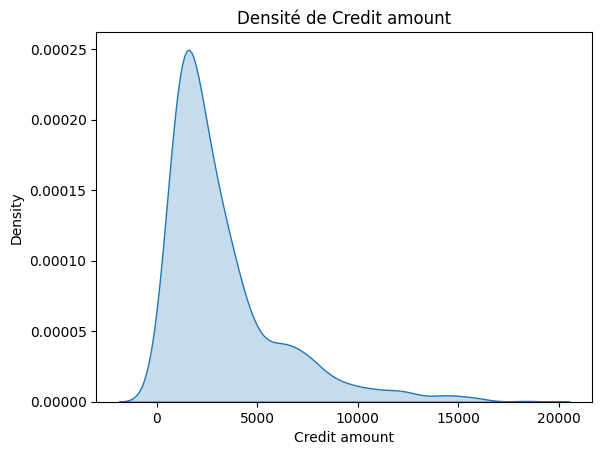

In [ ]:
# Visualiser Credit amount avec une densité

sns.kdeplot(x='Credit amount', data=df, fill=True)
plt.xlabel('Credit amount')
plt.title("Densité de Credit amount")
plt.show()



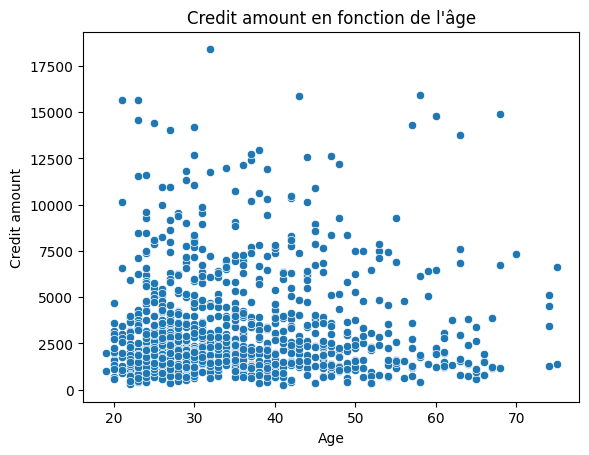

In [ ]:
# Visualiser Credit amount en fonction de l'âge

sns.scatterplot(x='Age', y='Credit amount', data=df)
plt.title("Credit amount en fonction de l'âge")
plt.xlabel('Age')
plt.ylabel('Credit amount')
plt.show()

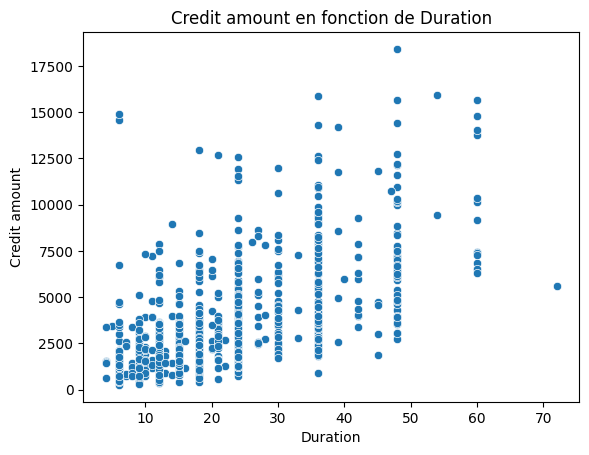

In [ ]:
# Visualiser Credit amount en fonction de Duration

sns.scatterplot(x='Duration', y='Credit amount', data=df)
plt.title("Credit amount en fonction de Duration")
plt.xlabel('Duration')
plt.ylabel('Credit amount')
plt.show()

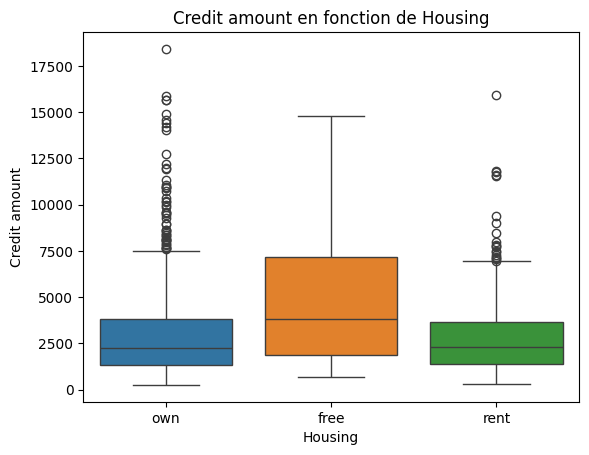

In [ ]:
# Visualiser Credit amount en fonction de housing

sns.boxplot(x='Housing', y='Credit amount', data=df, hue='Housing')
plt.title("Credit amount en fonction de Housing")
plt.xlabel('Housing')
plt.ylabel('Credit amount')
plt.show()

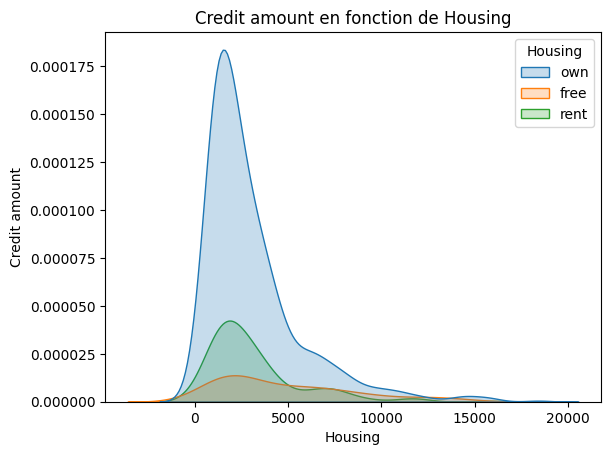

In [ ]:
# Visualiser Credit amount en fonction de housing sous forme de distribution

sns.kdeplot(x='Credit amount', hue = 'Housing', fill = True, data=df)
plt.title("Credit amount en fonction de Housing")
plt.xlabel('Housing')
plt.ylabel('Credit amount')
plt.show()

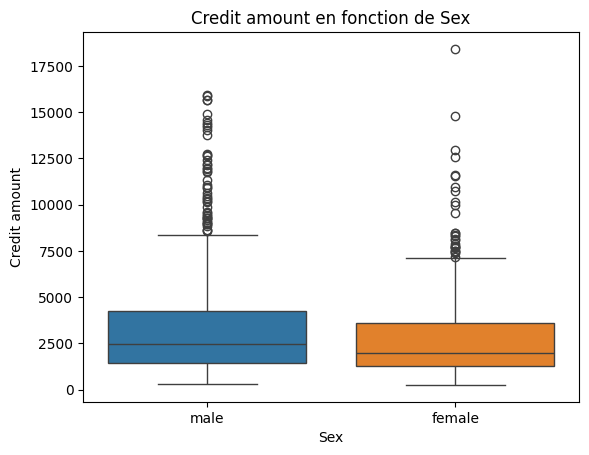

In [ ]:
# Visualiser Credit amount en fonction de Sex

sns.boxplot(x='Sex', y='Credit amount', data=df, hue='Sex')
plt.xlabel('Sex')
plt.ylabel('Credit amount')
plt.title("Credit amount en fonction de Sex")
plt.show()

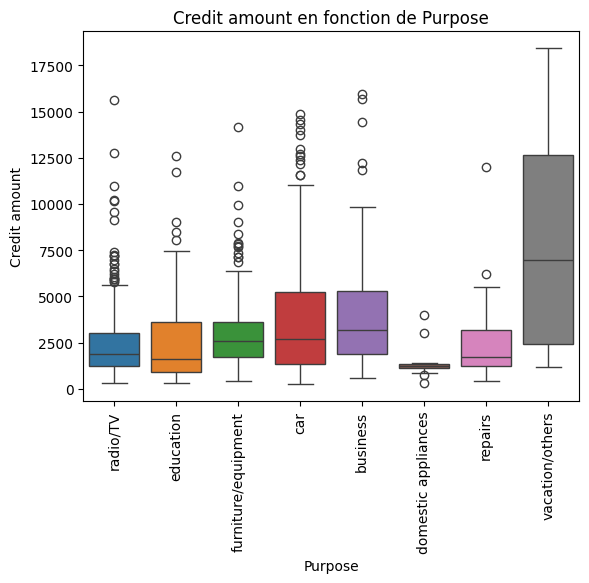

In [ ]:
# Visualiser Credit amount en fonction de Purpose

sns.boxplot(x='Purpose', y='Credit amount', data=df, hue='Purpose')
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.title("Credit amount en fonction de Purpose")
plt.xticks(rotation=90)
plt.show()

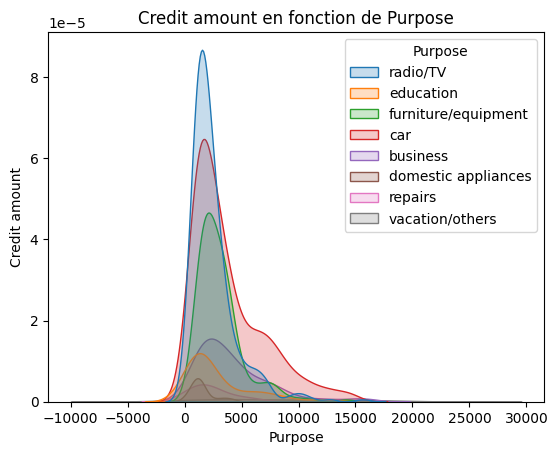

In [ ]:
# Visualiser Credit amount en fonction de Purpose en densité

sns.kdeplot(x = 'Credit amount', hue = 'Purpose', fill = True, data=df)
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.title("Credit amount en fonction de Purpose")
plt.show()

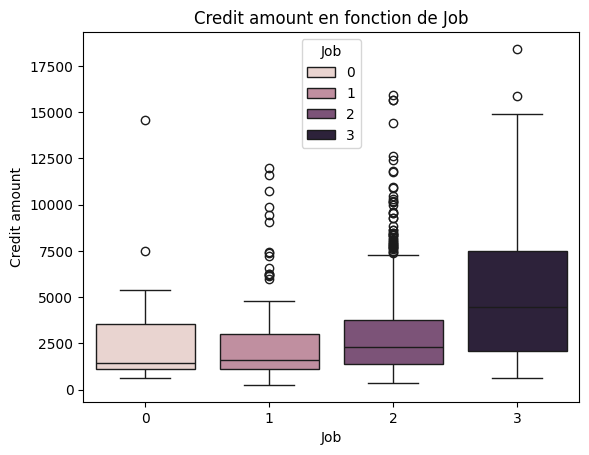

In [ ]:
# Visualiser Credit amount en fonction de Job

sns.boxplot(x='Job', y='Credit amount', data=df, hue='Job')
plt.xlabel('Job')
plt.ylabel('Credit amount')
plt.title("Credit amount en fonction de Job")
plt.show()

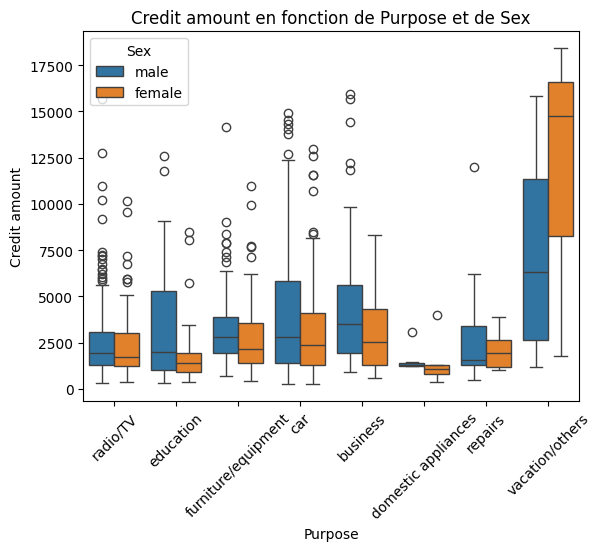

In [ ]:
sns.boxplot(data=df, x="Purpose", y="Credit amount", hue="Sex")
plt.xlabel('Purpose')
plt.ylabel('Credit amount')
plt.title("Credit amount en fonction de Purpose et de Sex")
plt.xticks(rotation=45)
plt.show()